<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 5.21}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Alumna:} & Marisol Luna Méndez \\[6pt]
\textbf{Fecha de realización:} & 13/05/2026
\end{array}

</center>



---

**UNAM y la creadora del presente notebook, no guarda relación alguna con las marcas mencionadas como ejemplo. Las marcas son propiedad de sus titulares conforme a la legislación aplicable, se utilizan con fines académicos y didácticos, por lo que no existen fines de lucro, relación publicitaria o de patrocinio.

---

In [ ]:
!pip install opencv-python

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Afin. py

def estima_afin(s,t):
  num = s.shape[1]
  M =np.zeros((2 * num, 6))
  for i in range (num):
    M[2 * i, 0] = s[0,i]
    M[2 * i, 1] = s[1,i]
    M[2 * i, 4] = 1
    M[2 * i + 1, 2] = s[0,i]
    M[2 * i + 1, 3] = s[1,i]
    M[2 * i + 1, 5] = 1

  b = t.T.reshape((2 * num, 1))
  theta = np.linalg.lstsq(M,b, rcond=None)[0]

  X = theta[:4].reshape((2,2))
  Y = theta[4:]
  return X,Y

In [ ]:
# Ransac.py

K = 3
threshold = 1
ITER_NUM = 2000


def residual_lengths(X, Y, s, t):
  e = np.dot(X,s) + Y
  diff_square = np.power(e - t,2)
  residual = np.sqrt(np.sum(diff_square, axis = 0))
  return residual


def ransac_fit(pts_s, pts_t):
  inliers_num = 0
  A = None
  t = None
  inliers = None

  for i in range(ITER_NUM):
    idx = np.random.randint(0, pts_s.shape[1],(K, 1))
    A_tmp, t_tmp = estima_afin(pts_s[:,idx], pts_t[:, idx])
    residual = residual_lengths(A_tmp, t_tmp, pts_s, pts_t)
    if not(residual is None):
      inliers_tmp = np.where(residual < threshold)
      inliers_num_tmp = len(inliers_tmp[0])
      if inliers_num_tmp > inliers_num:
        inliers_num = inliers_num_tmp
        inliers = inliers_tmp
        A = A_tmp
        t = t_tmp
      else:
        pass
  return A, t, inliers











In [ ]:
# Alinear.py

def extract_SIFT(img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  sift = cv2.SIFT_create()
  kp, desc = sift.detectAndCompute(img_gray, None)
  kp, desc = sift.detectAndCompute(img_gray, None)
  kp = np.array([p.pt for p in kp]).T
  return kp, desc

def match_SIFT(descriptor_source, descriptor_target):
  bf =cv2.BFMatcher()
  matches = bf.knnMatch(descriptor_source, descriptor_target, k=2)
  pos = np.array([],dtype=np.int32).reshape((0,2))
  matches_num = len(matches)
  for i in range(matches_num):
    if matches[i][0].distance <= 0.8 * matches[i][1].distance:
      temp = np.array([matches[i][0].queryIdx,
                      matches[i][0].trainIdx])
      pos = np.vstack((pos, temp))
  return pos


def affine_matrix(s,t,pos):
    s = s[:, pos[:,0]]
    t = t[:, pos[:,1]]
    _,_, inliers = ransac_fit(s,t)
    s = s[:,inliers[0]]
    t = t[:,inliers[0]]

    A, t = estima_afin(s,t)
    M = np.hstack((A, t))
    return M


Implementación

In [ ]:
import sys
# Esta línea agrega la ruta de la carpeta principal de Colab a la búsqueda de Python
sys.path.append('/content/')
#import hamburguesa
#import Alinear
#hamburguesa.hacer_hamburguesa("doble","queso", "tocino", "jamón")

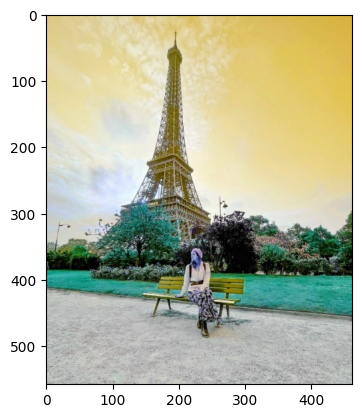

In [ ]:
img_source = cv2.imread("torre1.jpg")
img_target = cv2.imread("torre2.jpg")
plt.imshow(img_source)

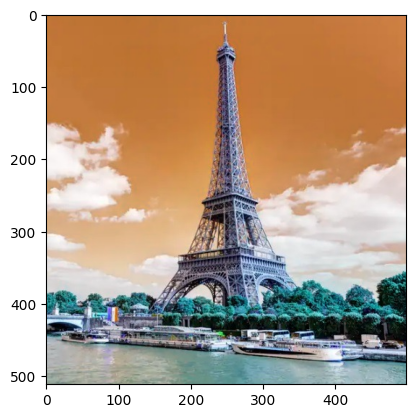

In [ ]:
img_source = cv2.imread("torre1.jpg")
img_target = cv2.imread("torre2.jpg")


plt.imshow(img_target)

In [ ]:
keypoint_source, descriptor_source = extract_SIFT(img_source)
keypoint_target, descriptor_target = extract_SIFT(img_target)




In [ ]:

pos = match_SIFT(descriptor_source, descriptor_target)




In [ ]:
H = affine_matrix(keypoint_source, keypoint_target, pos)


/tmp/ipykernel_28222/3177066115.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  M[2 * i, 0] = s[0,i]
/tmp/ipykernel_28222/3177066115.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  M[2 * i, 1] = s[1,i]
/tmp/ipykernel_28222/3177066115.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  M[2 * i + 1, 2] = s[0,i]
/tmp/ipykernel_28222/3177066115.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. 

In [ ]:
rows, cols, _ = img_target.shape
warp = cv2.warpAffine(img_source, H, (cols,rows))
merge = np.uint8(img_target * 0.5 + warp *0.5)

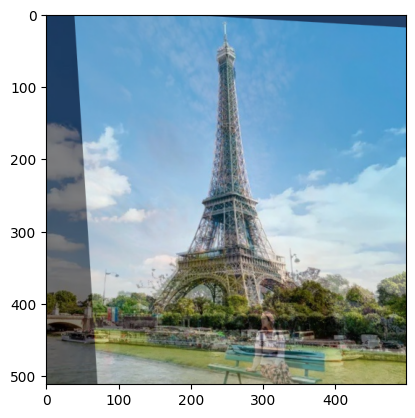

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(merge, cv2.COLOR_BGR2RGB))

<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>